In [43]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import wandb

In [2]:
api = wandb.Api()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/danyoungday/.netrc.


In [56]:
def load_history(api: wandb.Api, run_id: str, columns: list[str]) -> pd.DataFrame:
    run = api.run(f"robosuite/{run_id}")
    history = pd.DataFrame(run.scan_history(keys=columns))
    return history

eval_columns = ["eval/success_rate", "eval/mean_reward", "global_step"]
curriculum_columns = ["curriculum/weight/reach_weight", "curriculum/weight/grasp_weight", "curriculum/weight/lift_height_weight", "curriculum/weight/success_weight"]

name_to_run = {
    "default": "2e7hxhap",
    "curriculum": "73ez7wn3",
    "novideo": "tyos95zc"
}

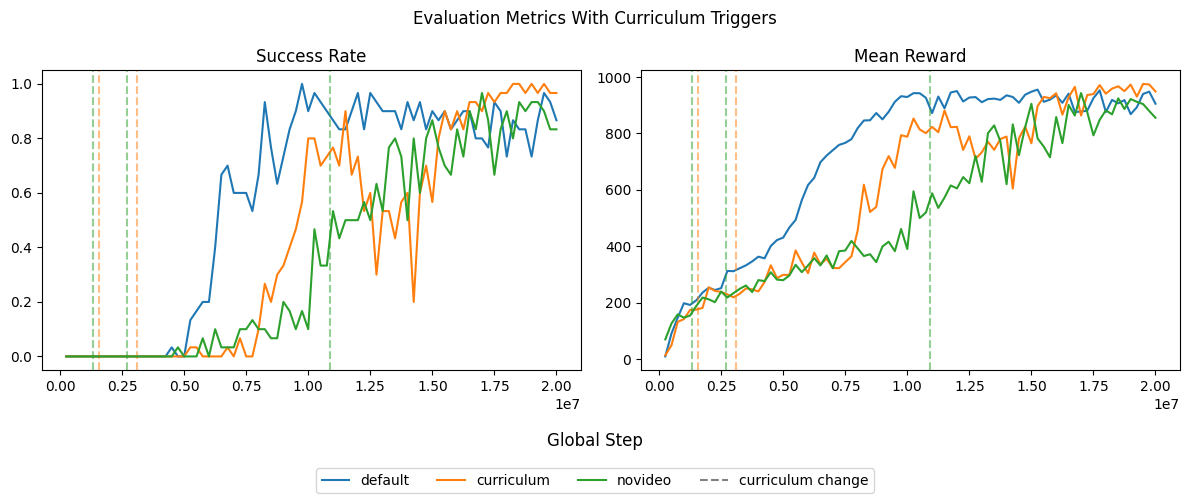

In [45]:
def plot_eval():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    for i, (key, run_id) in enumerate(name_to_run.items()):
        success_rate_history = load_history(api, run_id, ["eval/success_rate", "global_step"])
        axes[0].plot(success_rate_history["global_step"], success_rate_history["eval/success_rate"], label=key)

        eval_reward_history = load_history(api, run_id, ["eval/mean_reward", "global_step"])
        axes[1].plot(eval_reward_history["global_step"], eval_reward_history["eval/mean_reward"], label=key)

        # We want to plot the global step where the curriculum fired
        if key in ["curriculum", "novideo"]:
            curriculum_stage_history = load_history(api, run_id, ["curriculum/stage", "global_step"])
            for _, row in curriculum_stage_history.iterrows():
                axes[0].axvline(x=row["global_step"], color=f"C{i}", linestyle="--", alpha=0.5)
                axes[1].axvline(x=row["global_step"], color=f"C{i}", linestyle="--", alpha=0.5)

    
    axes[0].set_title("Success Rate")
    axes[1].set_title("Mean Reward")
    fig.suptitle("Evaluation Metrics With Curriculum Triggers")
    fig.supxlabel("Global Step", y=0.1)

    # Shared legend at bottom, below supxlabel, plus a "curriculum change" entry
    handles, labels = axes[0].get_legend_handles_labels()
    handles.append(Line2D([0], [0], color="gray", linestyle="--", label="curriculum change"))
    labels.append("curriculum change")
    fig.legend(handles, labels, loc="lower center", ncol=len(handles), bbox_to_anchor=(0.5, 0.0))

    fig.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

plot_eval()

In [51]:
def create_curriculum_history(run_id: str, curriculum_columns: list[str]) -> pd.DataFrame:
    """
    Since the curriculum columns are slightly offset by the step, we just align them by indices
    """
    curriculum = {}
    for col in curriculum_columns:
        history = load_history(api, run_id, [col])
        curriculum_col = history[col].values
        curriculum[col] = curriculum_col

    return curriculum

In [57]:
curriculum_history = create_curriculum_history(name_to_run["curriculum"], curriculum_columns)
no_video_history = create_curriculum_history(name_to_run["novideo"], curriculum_columns)

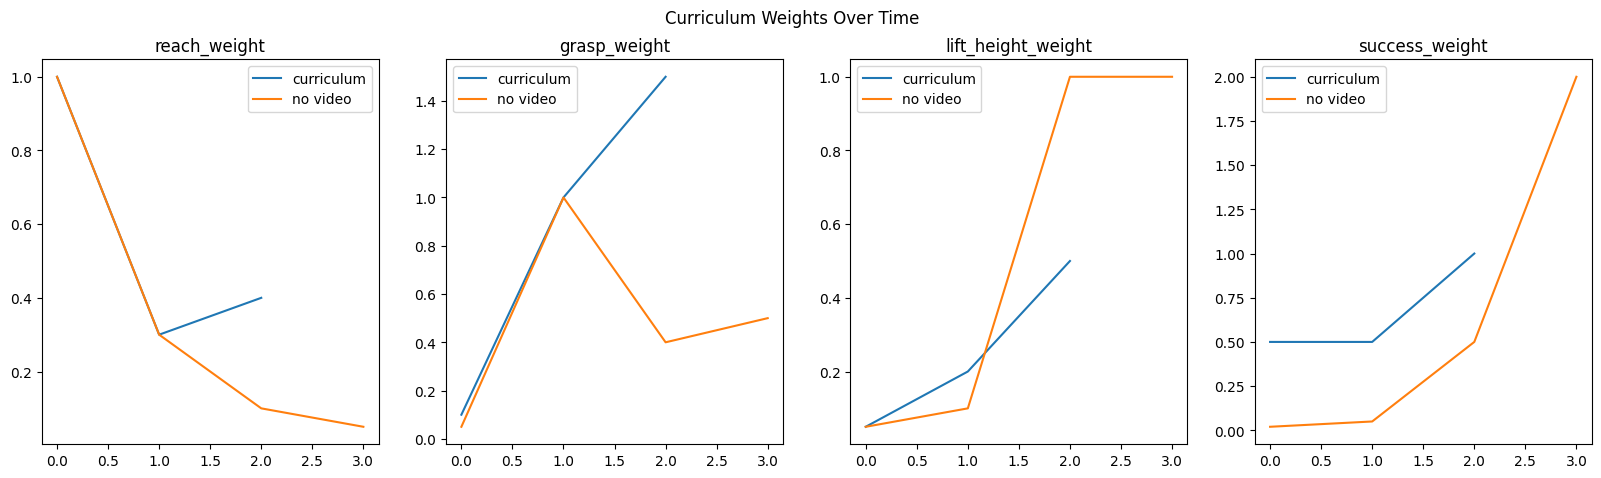

In [58]:
def plot_curriculum(curriculum_history: dict[str, np.ndarray], no_video_history: dict[str, np.ndarray]):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for i, (col, values) in enumerate(curriculum_history.items()):
        axes[i].plot(values, label="curriculum")
        axes[i].plot(no_video_history[col], label="no video")
        axes[i].set_title(col.split("/")[-1])
        axes[i].legend()
    fig.suptitle("Curriculum Weights Over Time")
    plt.show()

plot_curriculum(curriculum_history, no_video_history)